In [ ]:
import kagglehub
xhlulu_140k_real_and_fake_faces_path = kagglehub.dataset_download('xhlulu/140k-real-and-fake-faces')

print('Data source import complete.')


Data source import complete.


# Introduction to Deepfake Detection
Deepfakes are synthetic media (usually videos or images) created using deep learning techniques. They convincingly replace a person’s likeness in existing media with someone else’s, often leading to misinformation and potential harm. Detecting deepfakes is crucial for maintaining trust in visual content.

**on this project we will use dataset** ***140k Real and Fake Faces***

This dataset consists of all 70k REAL faces from the Flickr dataset collected by Nvidia, as well as 70k fake faces sampled from the 1 Million FAKE faces (generated by StyleGAN) that was provided by Bojan.

In this dataset, I convenient combined both dataset, resized all the images into 256px, and split the data into train, validation and test set. I also included some CSV files for convenience.

In [ ]:
import os
import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.applications import Xception
from sklearn.metrics import classification_report
from tensorflow.keras import Model


In [ ]:
train_data = pd.read_csv("/kaggle/input/140k-real-and-fake-faces/train.csv")
test_data  = pd.read_csv("/kaggle/input/140k-real-and-fake-faces/test.csv")
validation_data = pd.read_csv("/kaggle/input/140k-real-and-fake-faces/valid.csv")

In [ ]:
path="/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake"

In [ ]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


# Preprocessing and Augmentation
The ImageDataGenerator is a powerful tool for data augmentation and preprocessing in deep learning. It generates batches of augmented image data on-the-fly during training.

In [ ]:
train_image_generator = ImageDataGenerator(rescale=1./255.,preprocessing_function=preprocess_input)

train_data_generator = train_image_generator.flow_from_dataframe(
    dataframe=train_data,
    directory=path,
    x_col ='path',
    y_col ='label_str',
    color_mode="rgb",
    target_size=(256, 256),
    class_mode="binary",
    batch_size=32,
    shuffle = True
)


Found 100000 validated image filenames belonging to 2 classes.


In [ ]:
validation_image_generator = ImageDataGenerator(rescale=1./255.,preprocessing_function=preprocess_input)
test_image_generator = ImageDataGenerator(rescale=1./255.,preprocessing_function=preprocess_input)

validation_data_generator = validation_image_generator.flow_from_dataframe(
    dataframe=validation_data,
    directory=path,
    x_col ='path',
    y_col ='label_str',
    color_mode="rgb",
    target_size=(256, 256),
    class_mode="binary",
    batch_size=32,
    shuffle = True
)


test_data_generator = test_image_generator.flow_from_dataframe(
    dataframe=test_data,
    directory=path,
    x_col ='path',
    y_col ='label_str',
    color_mode="rgb",
    target_size=(256, 256),
    class_mode="binary",
    batch_size=32,
    shuffle = False
)


Found 20000 validated image filenames belonging to 2 classes.
Found 20000 validated image filenames belonging to 2 classes.


# visualization

In [ ]:
labels = train_data_generator.class_indices
class_names = list(labels.keys())
print('class names:',class_names)

class names: ['fake', 'real']


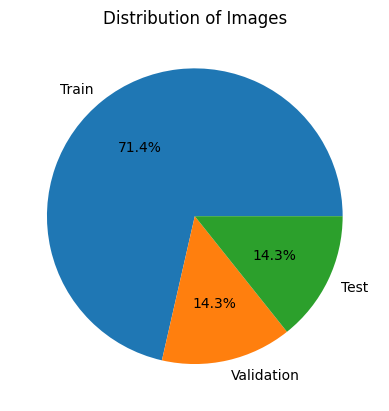

In [ ]:
import matplotlib.pyplot as plt

labels = ["Train", "Validation", "Test"]
counts = [len(train_data), len(validation_data), len(test_data)]

fig, ax = plt.subplots()
ax.pie(counts, labels=labels, autopct="%1.1f%%")
ax.set_title("Distribution of Images")
plt.show()


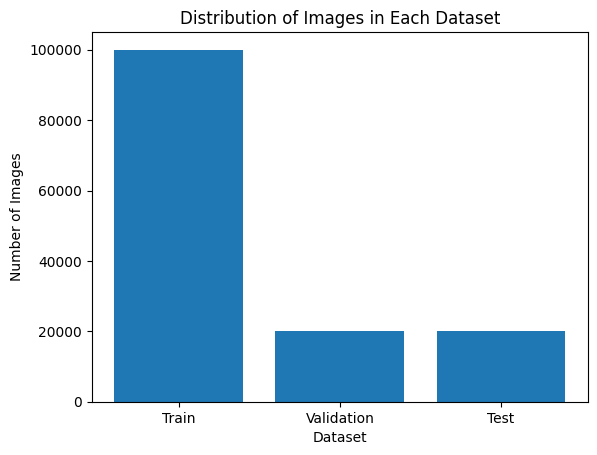

In [ ]:
import matplotlib.pyplot as plt

train_size = len(train_data)
validation_size = len(validation_data)
test_size = len(test_data)

fig, ax = plt.subplots()
x = ['Train', 'Validation', 'Test']
y = [train_size, validation_size, test_size]
ax.bar(x, y)
ax.set_xlabel('Dataset')
ax.set_ylabel('Number of Images')
ax.set_title('Distribution of Images in Each Dataset')

plt.show()

# Convolutional Neural Networks (CNNs)
CNNs have been widely used for image classification tasks. They excel at learning hierarchical features from raw pixel data. In the context of deepfake detection, CNNs can analyze patterns and features in images to distinguish between real and manipulated content.

In [ ]:
model_cnn = Sequential()

model_cnn.add(Conv2D(32,kernel_size=(3, 3), activation='relu', input_shape=(256, 256, 3)))
model_cnn.add(MaxPooling2D((2, 2)))
model_cnn.add(Conv2D(64, (3, 3), activation='relu'))
model_cnn.add(MaxPooling2D((2, 2)))
model_cnn.add(Conv2D(64, (3, 3), activation='relu'))
model_cnn.add(MaxPooling2D((2, 2)))
model_cnn.add(Dropout(0.2))
model_cnn.add(Flatten())
model_cnn.add(Dense(64, activation='relu'))
model_cnn.add(Dropout(0.2))
model_cnn.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,742,849 (14.28 MB)

 Trainable params: 3,742,849 (14.28 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_cnn.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [ ]:
with tf.device('/GPU:0'):
    history = model_cnn.fit(train_data_generator, epochs=10, validation_data=validation_data_generator)

Epoch 1/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 420s 134ms/step - accuracy: 0.9248 - loss: 0.1882 - val_accuracy: 0.9500 - val_loss: 0.1300
Epoch 2/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 317s 102ms/step - accuracy: 0.9627 - loss: 0.0995 - val_accuracy: 0.9689 - val_loss: 0.0873
Epoch 3/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 323s 103ms/step - accuracy: 0.9757 - loss: 0.0650 - val_accuracy: 0.9686 - val_loss: 0.0875
Epoch 4/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 312s 100ms/step - accuracy: 0.9806 - loss: 0.0522 - val_accuracy: 0.9728 - val_loss: 0.0781
Epoch 5/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 311s 99ms/step - accuracy: 0.9827 - loss: 0.0445 - val_accuracy: 0.9724 - val_loss: 0.0825
Epoch 6/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 303s 97ms/step - accuracy: 0.9863 - loss: 0.0388 - val_accuracy: 0.9733 - val_loss: 0.0785
Epoch 7/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 303s 97ms/step - accuracy: 0.9872 - loss: 0.0364 - val_accuracy: 0.9768 - val_loss: 0.0684
Epoch 8/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 291s 93ms/step - accura

In [ ]:
test_loss, test_accuracy = model_cnn.evaluate(test_data_generator)
print(f'Loss: {test_loss}, Accuracy: {test_accuracy}')

625/625 ━━━━━━━━━━━━━━━━━━━━ 137s 220ms/step - accuracy: 0.9819 - loss: 0.0534
Loss: 0.06933354586362839, Accuracy: 0.978600025177002


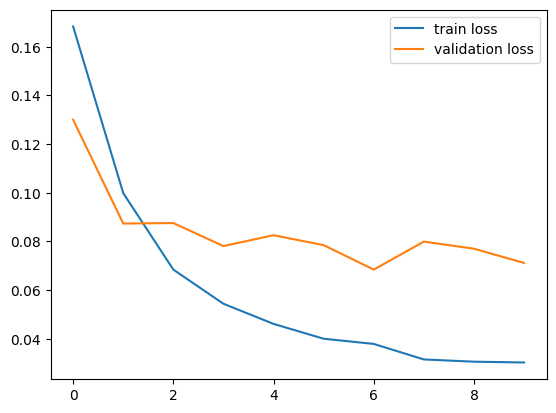

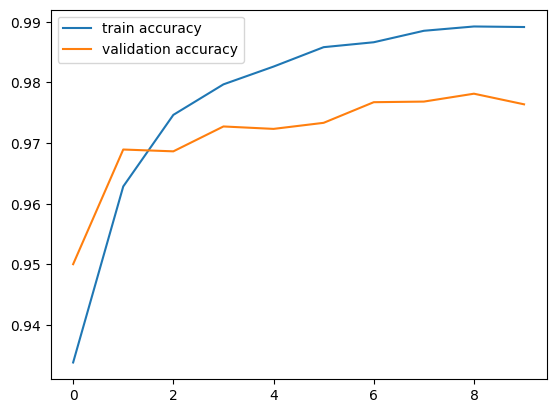

In [ ]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.legend()
plt.show()


plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.legend()
plt.show()


625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 79ms/step


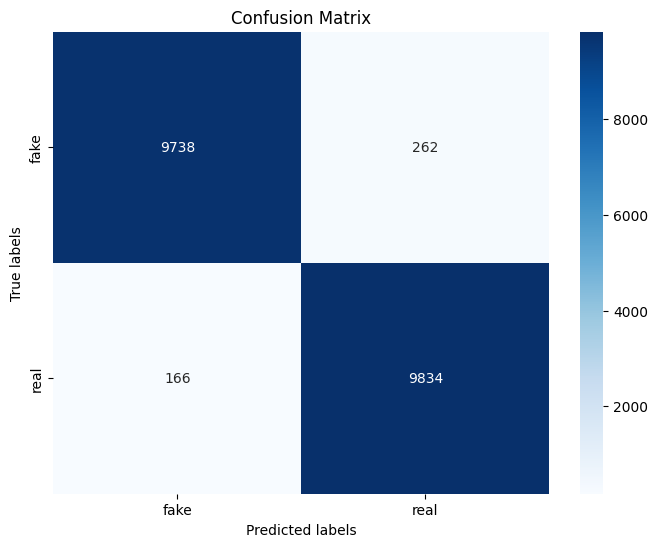

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

predictions = model_cnn.predict(test_data_generator)
predicted_labels = np.where(predictions > 0.5, 1, 0)
true_labels = test_data_generator.classes

conf_matrix = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_data_generator.class_indices,
            yticklabels=test_data_generator.class_indices)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
class_names = list(test_data_generator.class_indices.keys())
report = classification_report(true_labels, predicted_labels, target_names=class_names)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

        fake       0.98      0.97      0.98     10000
        real       0.97      0.98      0.98     10000

    accuracy                           0.98     20000
   macro avg       0.98      0.98      0.98     20000
weighted avg       0.98      0.98      0.98     20000



# XceptionNet
XceptionNet is a deep learning architecture based on CNNs. It was designed to improve the efficiency of feature extraction by replacing standard convolutional layers with depthwise separable convolutions. XceptionNet has been successfully applied to various computer vision tasks, including deepfake detection.

In [ ]:
base_model = Xception(weights='imagenet',include_top=False,input_shape=(256, 256, 3))


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
for layer in base_model.layers:
    layer.trainable = False

Xception_model = Sequential()
Xception_model.add(base_model)
Xception_model.add(Flatten())
Xception_model.add(BatchNormalization())
Xception_model.add(Dense(256, activation='relu'))
Xception_model.add(Dropout(0.5))
Xception_model.add(Dense(128, activation='relu'))
Xception_model.add(Dropout(0.5))
Xception_model.add(BatchNormalization())
Xception_model.add(Dense(1, activation='sigmoid'))

Xception_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 8, 8, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 131072)         │       524,288 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    33,554,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,973,993 (209.71 MB)

 Trainable params: 33,850,113 (129.13 MB)

 Non-trainable params: 21,123,880 (80.58 MB)

In [ ]:
Xception_model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
with tf.device('/GPU:0'):
  history = Xception_model.fit(train_data_generator ,epochs = 10,validation_data= (validation_data_generator))
  print(history.history)

Epoch 1/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 318s 102ms/step - accuracy: 0.7319 - loss: 0.5492 - val_accuracy: 0.8421 - val_loss: 0.3531
Epoch 2/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 328s 105ms/step - accuracy: 0.8511 - loss: 0.3460 - val_accuracy: 0.8650 - val_loss: 0.3135
Epoch 3/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 309s 99ms/step - accuracy: 0.8777 - loss: 0.2904 - val_accuracy: 0.8879 - val_loss: 0.2669
Epoch 4/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 309s 99ms/step - accuracy: 0.8959 - loss: 0.2517 - val_accuracy: 0.8919 - val_loss: 0.2579
Epoch 5/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 313s 100ms/step - accuracy: 0.9119 - loss: 0.2162 - val_accuracy: 0.9046 - val_loss: 0.2310
Epoch 6/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 313s 100ms/step - accuracy: 0.9275 - loss: 0.1804 - val_accuracy: 0.8949 - val_loss: 0.2638
Epoch 7/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 319s 102ms/step - accuracy: 0.9379 - loss: 0.1592 - val_accuracy: 0.9097 - val_loss: 0.2287
Epoch 8/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 314s 100ms/step - accu

In [ ]:
test_loss, test_accuracy = Xception_model.evaluate(test_data_generator)
print(f'Loss: {test_loss}, Accuracy: {test_accuracy}')

625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 81ms/step - accuracy: 0.9030 - loss: 0.2655
Loss: 0.22897519171237946, Accuracy: 0.9151999950408936


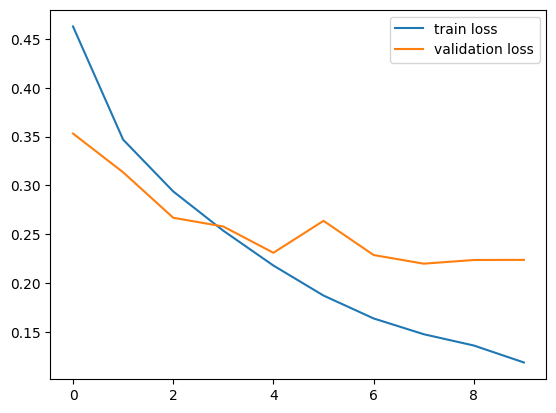

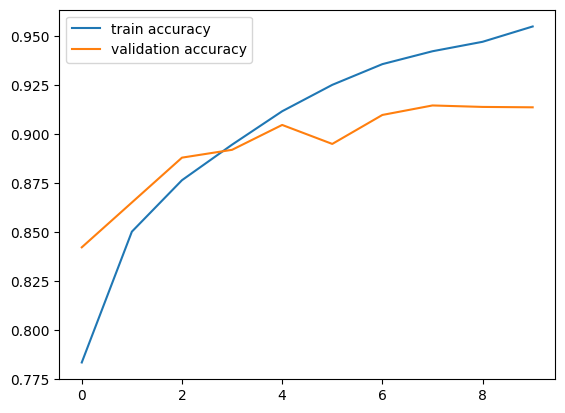

In [ ]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.legend()
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

predictions = Xception_model.predict(test_data_generator)
predicted_labels = np.where(predictions > 0.5, 1, 0)
true_labels = test_data_generator.classes
conf_matrix = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_data_generator.class_indices,
            yticklabels=test_data_generator.class_indices)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
class_names = list(test_data_generator.class_indices.keys())
report = classification_report(true_labels, predicted_labels, target_names=class_names)

print("Classification Report:")
print(report)
